#### LAB NUMBER - 01
#### DATE - 28/01/2026
#### NAME - R K LARIKA
#### ROLL NO - CS23B1028

#### QUESTION 1

- Implement the simple neural network algorithm from scratch in Python.
- Initialize the weights with [0 0 0] and a learning rate of 0.0001.
- For each iteration, calculate the output of the simple neural network for each input in the training set.
- Use MSE to computer the error for all samples
- Update the weights using the gradient descent procedure.
- Repeat the above steps until the simple neural network converges or a maximum number of iterations is reached.
- Test the trained simple neural network on a separate test set, explain how you came up with the test set.
- Use the step function as an  activation function in the output layer and sigmoid function for other layers.

- Use the IRIS Dataset for the above, considering all four features: sepal length, sepal width, petal length, and petal width, but only two classes -  Setosa, and Versicolor.  Drop the feature vectors of the other class. 


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv("iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
data = data[data["Species"] != "Iris-virginica"]
data['Species'] = data['Species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1
})

In [5]:
X = data[["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]].values
Y = data["Species"].values.reshape(-1,1)

print(X.shape)
print(Y.shape)


(100, 4)
(100, 1)


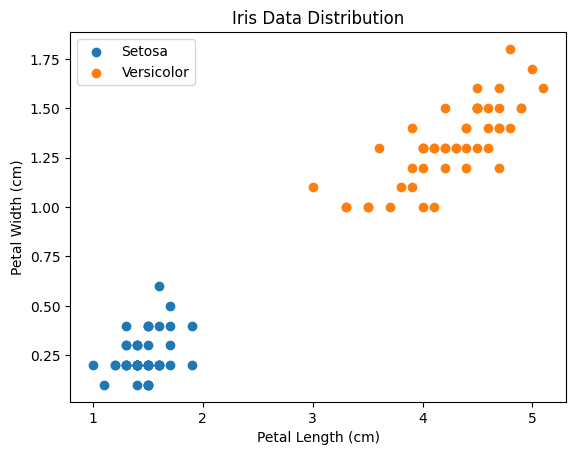

In [6]:
import matplotlib.pyplot as plt

setosa = data[data["Species"] == 0]
versicolor = data[data["Species"] == 1]

plt.scatter(setosa["PetalLengthCm"], setosa["PetalWidthCm"], label="Setosa")
plt.scatter(versicolor["PetalLengthCm"], versicolor["PetalWidthCm"], label="Versicolor")

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Data Distribution")
plt.legend()
plt.show()


Linearly Separable Classes - We can use Simple NN

In [7]:
# Feature Normalisation
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [8]:
np.random.seed(0)

indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]


In [9]:

def step(x):    return np.where(x >= 0, 1, 0)


In [10]:
lr = 0.0001

W = np.zeros((4,1))   # 4 inputs, 1 output
B = np.zeros((1,1))


In [13]:
epochs = 10  
mse_list = []

for epoch in range(epochs):
    
    # Forward pass
    Z = np.dot(X_train, W) + B
    output = step(Z)
    
    # Error and MSE
    error = Y_train - output
    mse = np.mean(error**2)
    mse_list.append(mse)
    
    # Update weights (perceptron learning rule)
    W += lr * np.dot(X_train.T, error)
    B += lr * np.sum(error)
    
    if epoch % 2 == 0:
        print("Epoch:", epoch, "MSE:", mse)


Epoch: 0 MSE: 0.0
Epoch: 2 MSE: 0.0
Epoch: 4 MSE: 0.0
Epoch: 6 MSE: 0.0
Epoch: 8 MSE: 0.0


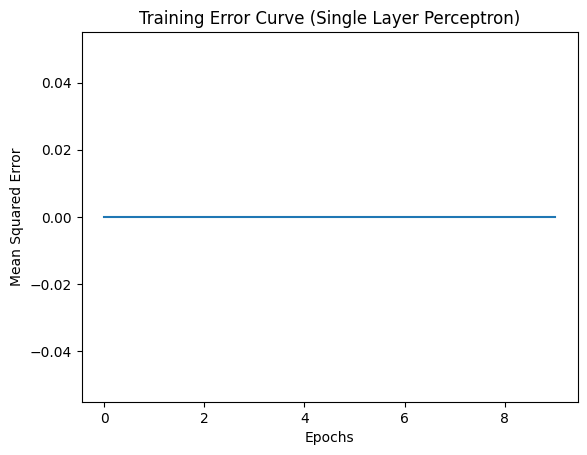

In [14]:
plt.plot(mse_list)
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.title("Training Error Curve (Single Layer Perceptron)")
plt.show()


In [15]:
Z_test = np.dot(X_test, W) + B
predictions = step(Z_test)

accuracy = np.mean(predictions == Y_test) * 100
print("Test Accuracy:", accuracy, "%")


Test Accuracy: 100.0 %
